In [24]:
from mlkem_gpu.reduce_gpu import (
    barrett_reduce,
    montgomery_reduce,
)

import torch

x = torch.tensor(
    [3329, 3330, 5000, -1, 100000, -100000],
    dtype=torch.int64,
)

print("Input:")
print(x)

print("\nBarrett:")
print(barrett_reduce(x))

print("\nMontgomery:")
print(montgomery_reduce(x))

Input:
tensor([   3329,    3330,    5000,      -1,  100000, -100000])

Barrett:
tensor([    0,     1, -1658,    -1,   130,  -130], device='mps:0',
       dtype=torch.int16)

Montgomery:
tensor([    0,   169,  -566,  -169, -1333,  1333], device='mps:0',
       dtype=torch.int16)


In [2]:
import time
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

from mlkem_gpu.reduce_gpu import barrett_reduce, montgomery_reduce

In [21]:
output_dir = Path("../reports/figures")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = Path("../results/timings/reduce_benchmark_mac.csv")
#output_path = Path("../results/timings/reduce_benchmark_windows.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)

In [4]:
### Available Devices
available_devices = ["cpu"]

if torch.backends.mps.is_available():
    available_devices.append("mps")

if torch.cuda.is_available():
    available_devices.append("cuda")

available_devices

['cpu', 'mps']

In [5]:
### Timing Helper
def sync_device(device: str):
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps":
        torch.mps.synchronize()


def benchmark_reduce_function(
    func,
    function_name: str,
    device: str,
    size: int,
    repeats: int = 100,
):
    # Create random integer coefficients
    x = torch.randint(
        low=-100000,
        high=100000,
        size=(size,),
        dtype=torch.int64,
        device=device,
    )

    # Warm-up
    for _ in range(10):
        _ = func(x)

    sync_device(device)

    start = time.perf_counter()

    for _ in range(repeats):
        y = func(x)

    sync_device(device)

    end = time.perf_counter()

    total_time = end - start
    avg_time_ms = (total_time / repeats) * 1000
    throughput = size / (avg_time_ms / 1000)

    return {
        "function": function_name,
        "device": device,
        "input_size": size,
        "repeats": repeats,
        "avg_time_ms": avg_time_ms,
        "throughput_coeffs_per_sec": throughput,
    }

In [14]:
### Run Benchmarks

### How long does Barrett reduction take & How long does Barrett reduction take

### Coefficients
sizes = [
    256,
    1024,
    4096,
    16384,
    65536,
    262144,
    1_048_576,
    2_097_152,
    4_194_304,
    8_388_608,
]

results = []

for device in available_devices:
    for size in sizes:
        results.append(
            benchmark_reduce_function(
                func=barrett_reduce,
                function_name="barrett_reduce",
                device=device,
                size=size,
                repeats=100,
            )
        )

        results.append(
            benchmark_reduce_function(
                func=montgomery_reduce,
                function_name="montgomery_reduce",
                device=device,
                size=size,
                repeats=100,
            )
        )

df = pd.DataFrame(results)
df

,function,device,input_size,repeats,avg_time_ms,throughput_coeffs_per_sec
0,barrett_reduce,cpu,256,100,0.373691,6.850583e+05
1,montgomery_reduce,cpu,256,100,0.348226,7.351542e+05
2,barrett_reduce,cpu,1024,100,0.313380,3.267603e+06
3,montgomery_reduce,cpu,1024,100,0.292152,3.505029e+06
4,barrett_reduce,cpu,4096,100,0.251833,1.626475e+07
5,montgomery_reduce,cpu,4096,100,0.260263,1.573791e+07
6,barrett_reduce,cpu,16384,100,0.248967,6.580790e+07
7,montgomery_reduce,cpu,16384,100,0.262631,6.238405e+07
8,barrett_reduce,cpu,65536,100,0.240793,2.721670e+08
9,montgomery_reduce,cpu,65536,100,0.264940,2.473621e+08


In [15]:
### Save Results
df.to_csv(output_path, index=False)
output_path

PosixPath('../results/timings/reduce_benchmark_mac.csv')

In [16]:
from pathlib import Path
import pandas as pd

csv_file = output_path

df = pd.read_csv(csv_file)

print(f"Loaded: {csv_file}")
print(f"Rows: {len(df)}")

display(df.head())

Loaded: ../results/timings/reduce_benchmark_mac.csv
Rows: 40


,function,device,input_size,repeats,avg_time_ms,throughput_coeffs_per_sec
0,barrett_reduce,cpu,256,100,0.373691,6.850583e+05
1,montgomery_reduce,cpu,256,100,0.348226,7.351542e+05
2,barrett_reduce,cpu,1024,100,0.313380,3.267603e+06
3,montgomery_reduce,cpu,1024,100,0.292152,3.505029e+06
4,barrett_reduce,cpu,4096,100,0.251833,1.626475e+07


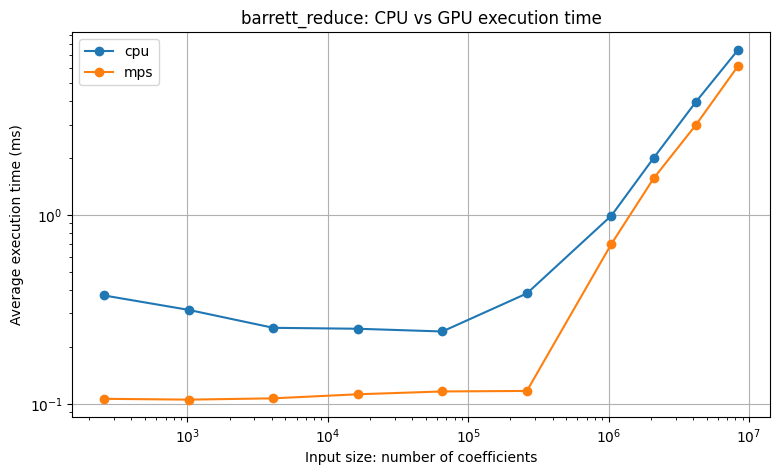

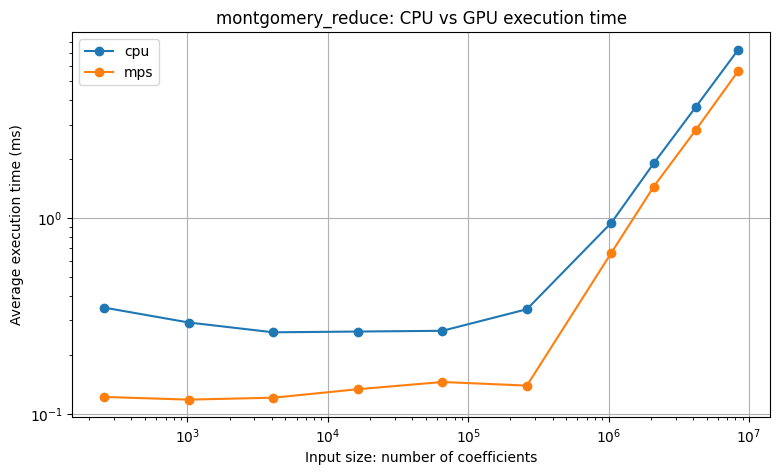

In [17]:
### Plot: Average Time
for function_name in df["function"].unique():
    subset = df[df["function"] == function_name]

    plt.figure(figsize=(9, 5))

    for device in subset["device"].unique():
        device_data = subset[subset["device"] == device]

        plt.plot(
            device_data["input_size"],
            device_data["avg_time_ms"],
            marker="o",
            label=device,
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Input size: number of coefficients")
    plt.ylabel("Average execution time (ms)")
    plt.title(f"{function_name}: CPU vs GPU execution time")
    plt.legend()
    plt.grid(True)
    plt.show()

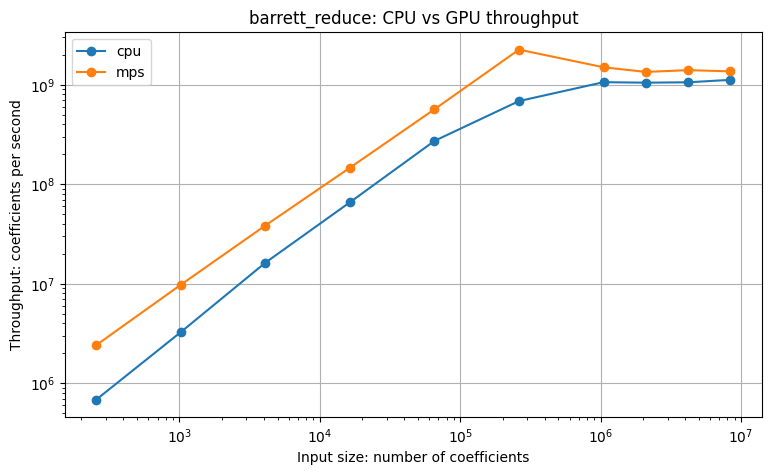

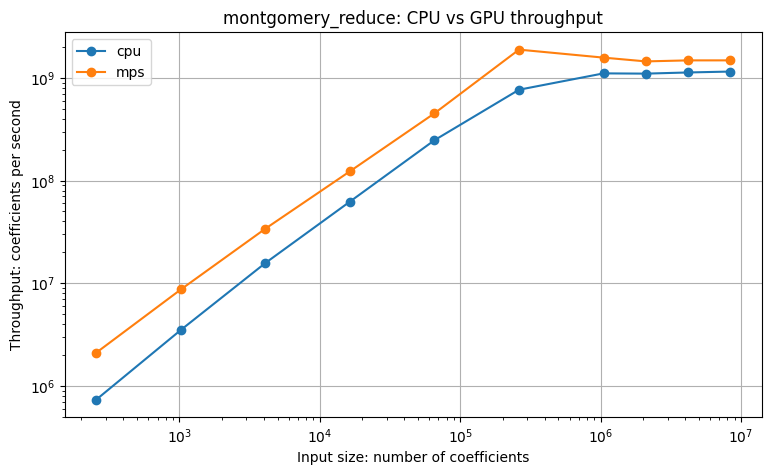

In [18]:
### Plot: Throughput
for function_name in df["function"].unique():
    subset = df[df["function"] == function_name]

    plt.figure(figsize=(9, 5))

    for device in subset["device"].unique():
        device_data = subset[subset["device"] == device]

        plt.plot(
            device_data["input_size"],
            device_data["throughput_coeffs_per_sec"],
            marker="o",
            label=device,
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Input size: number of coefficients")
    plt.ylabel("Throughput: coefficients per second")
    plt.title(f"{function_name}: CPU vs GPU throughput")
    plt.legend()
    plt.grid(True)
    plt.show()

,function,device,input_size,repeats,avg_time_ms,throughput_coeffs_per_sec,device_label
0,barrett_reduce,mps,256,100,0.105886,2.417698e+06,Mac M3 MPS
1,montgomery_reduce,mps,256,100,0.121532,2.106440e+06,Mac M3 MPS
2,barrett_reduce,mps,1024,100,0.104850,9.766294e+06,Mac M3 MPS
3,montgomery_reduce,mps,1024,100,0.117777,8.694391e+06,Mac M3 MPS
4,barrett_reduce,mps,4096,100,0.106500,3.846009e+07,Mac M3 MPS
5,montgomery_reduce,mps,4096,100,0.120474,3.399911e+07,Mac M3 MPS
6,barrett_reduce,mps,16384,100,0.111919,1.463914e+08,Mac M3 MPS
7,montgomery_reduce,mps,16384,100,0.133115,1.230819e+08,Mac M3 MPS
8,barrett_reduce,mps,65536,100,0.115832,5.657825e+08,Mac M3 MPS
9,montgomery_reduce,mps,65536,100,0.144944,4.521478e+08,Mac M3 MPS


Saved: ../reports/figures/barrett_reduce_mps_vs_cuda.png


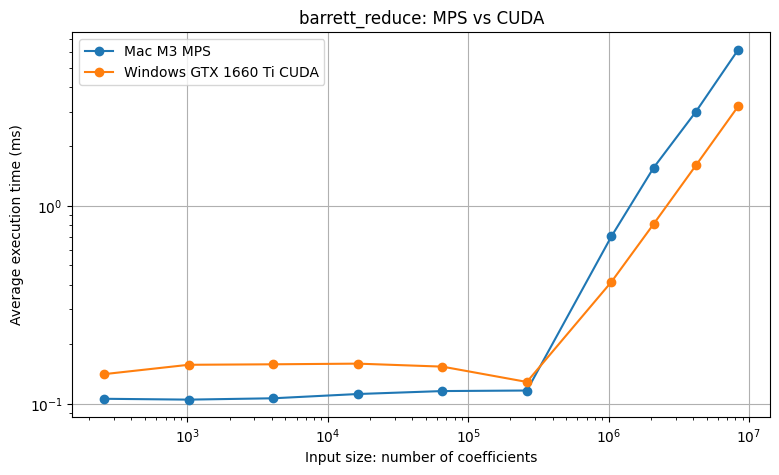

Saved: ../reports/figures/montgomery_reduce_mps_vs_cuda.png


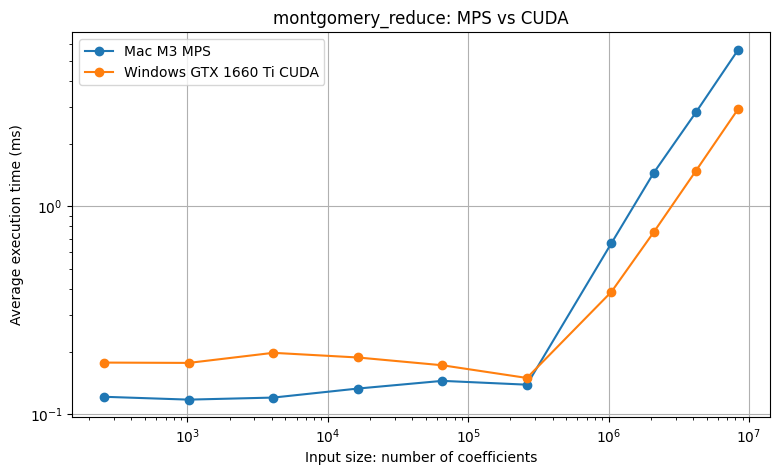

In [23]:
mac_csv = Path("../results/timings/reduce_benchmark_mac.csv")
windows_csv = Path("../results/timings/reduce_benchmark_windows.csv")

missing_files = []

if not mac_csv.exists():
    missing_files.append(str(mac_csv))

if not windows_csv.exists():
    missing_files.append(str(windows_csv))

if missing_files:
    print("Missing benchmark CSV file(s):")
    for file in missing_files:
        print(f"- {file}")

else:
    mac_df = pd.read_csv(mac_csv)
    windows_df = pd.read_csv(windows_csv)

    # Keep only GPU rows
    mac_mps_df = mac_df[mac_df["device"] == "mps"].copy()
    cuda_df = windows_df[windows_df["device"] == "cuda"].copy()

    mac_mps_df["device_label"] = "Mac M3 MPS"
    cuda_df["device_label"] = "Windows GTX 1660 Ti CUDA"

    combined_df = pd.concat(
        [mac_mps_df, cuda_df],
        ignore_index=True
    )

    display(combined_df)

    for function_name in combined_df["function"].unique():
        subset = combined_df[combined_df["function"] == function_name]

        plt.figure(figsize=(9, 5))

        for device_label in subset["device_label"].unique():
            device_data = subset[subset["device_label"] == device_label]

            plt.plot(
                device_data["input_size"],
                device_data["avg_time_ms"],
                marker="o",
                label=device_label,
            )

        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel("Input size: number of coefficients")
        plt.ylabel("Average execution time (ms)")
        plt.title(f"{function_name}: MPS vs CUDA")
        plt.legend()
        plt.grid(True)
    
        output_file = (
            output_dir /
            f"{function_name}_mps_vs_cuda.png"
        )
    
        plt.savefig(
            output_file,
            dpi=300,
            bbox_inches="tight"
        )
    
        print(f"Saved: {output_file}")

        
        plt.show()